In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import svm
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

dataset = pd.read_excel("fata/HousePricePrediction.xlsx")


object_cols = dataset.select_dtypes(include=['object']).columns
print("Categorical variables:", len(object_cols))

int_ = dataset.select_dtypes(include=['int64']).columns
print("Integer variables:", len(int_))

fl_cols = dataset.select_dtypes(include=['float64']).columns
print("Float variables:", len(fl_cols))

numerical_dataset = dataset.select_dtypes(include=['int64', 'float64'])


Categorical variables: 4
Integer variables: 6
Float variables: 3


In [5]:
print(fl_cols)
print(numerical_dataset.head(2))

Index(['BsmtFinSF2', 'TotalBsmtSF', 'SalePrice'], dtype='object')
   Id  MSSubClass  LotArea  OverallCond  YearBuilt  YearRemodified  \
0   0          60     8450            5       2003            2003   
1   1          20     9600            8       1976            1976   

   BsmtFinSF2  TotalBsmtSF  SalePrice  
0         0.0        856.0   208500.0  
1         0.0       1262.0   181500.0  


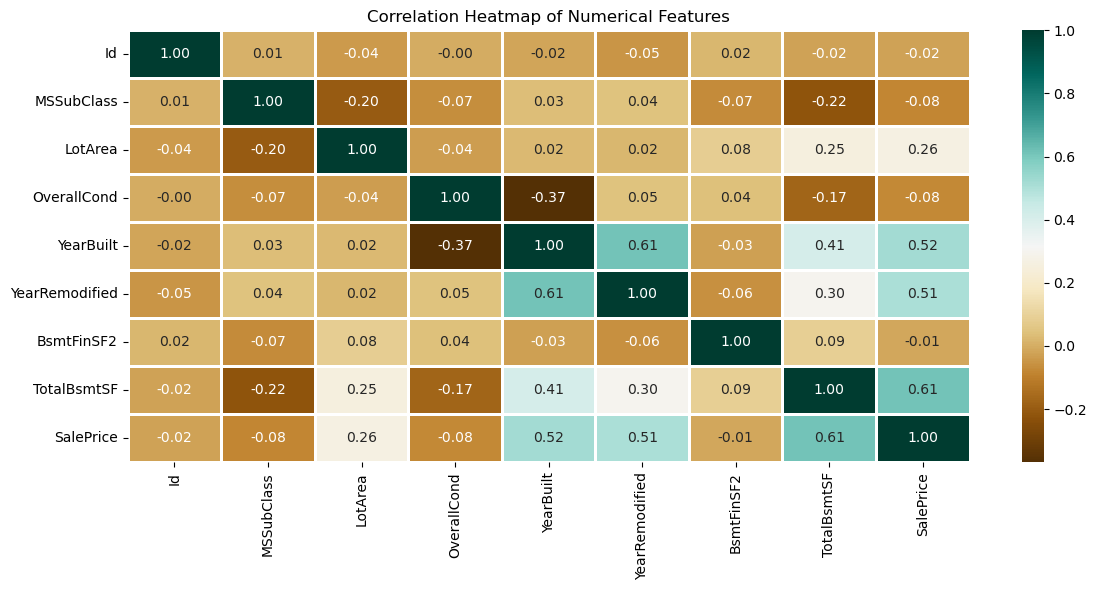

<Axes: xlabel='YearRemodified', ylabel='SalePrice'>

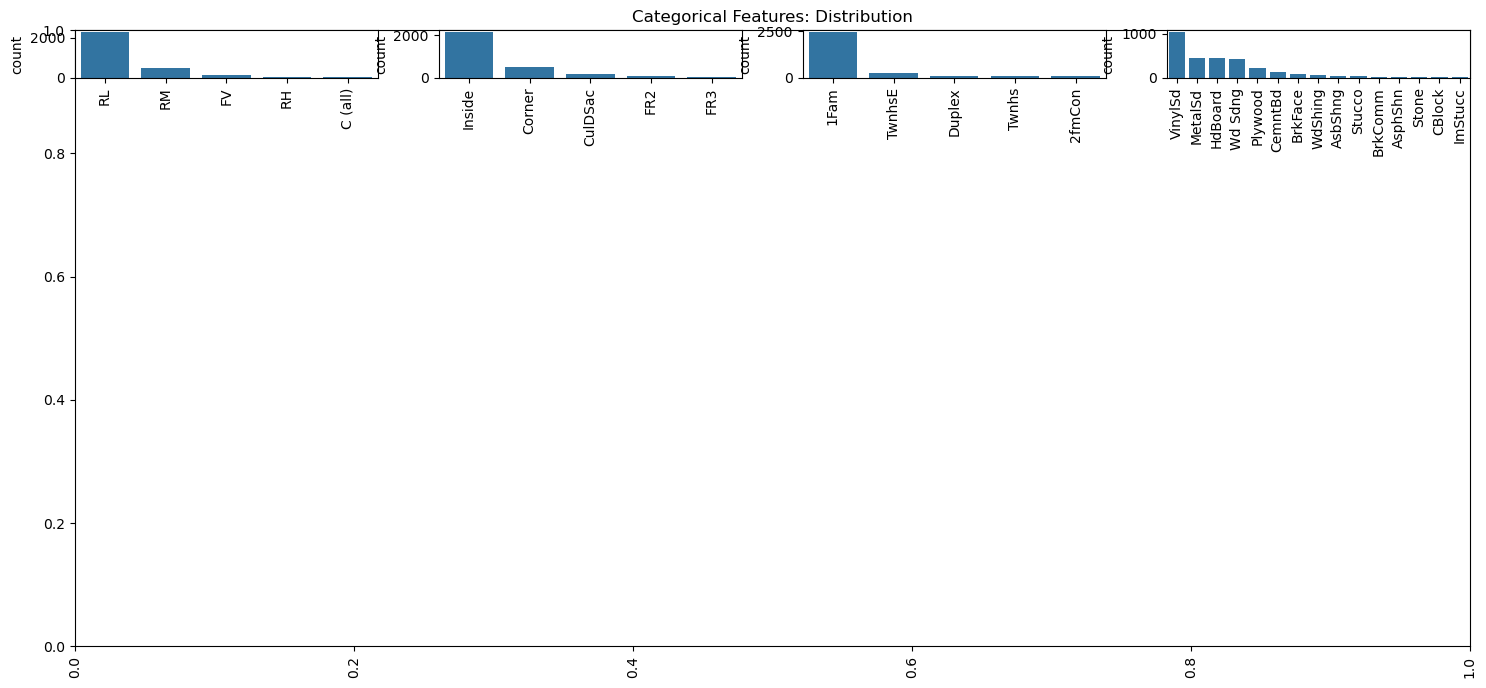

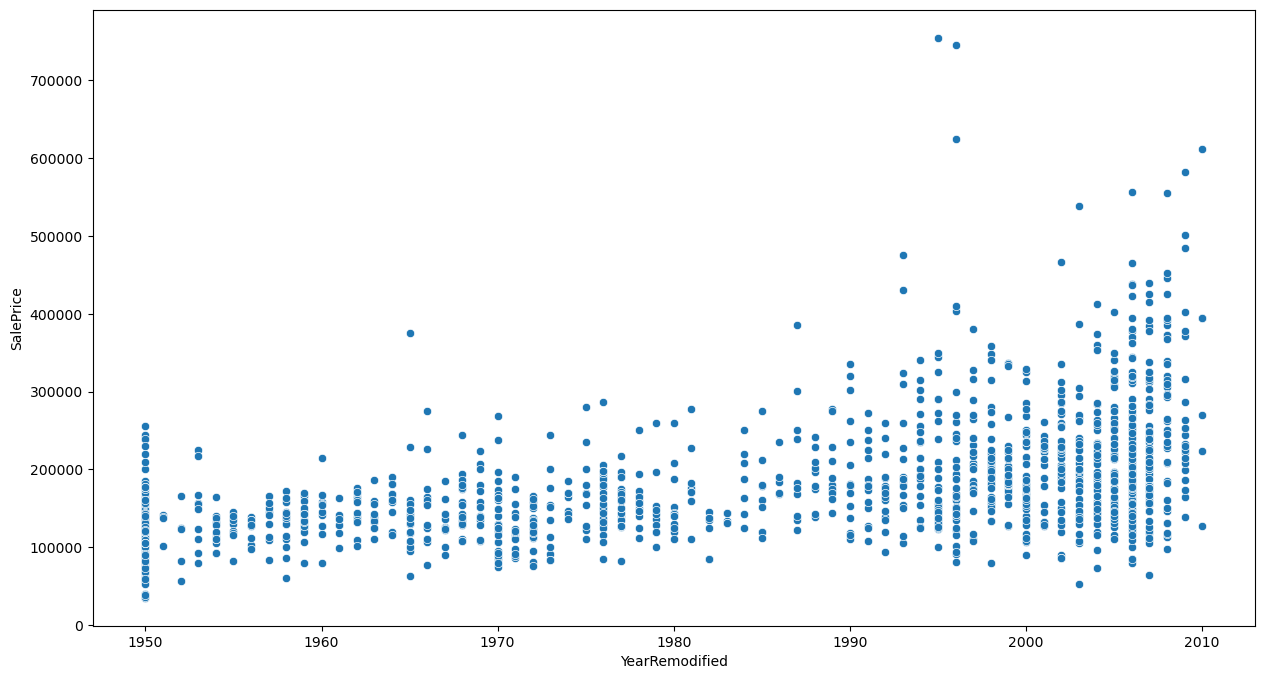

In [7]:
plt.figure(figsize=(12, 6))
sns.heatmap(numerical_dataset.corr(),
            cmap='BrBG',
            fmt='.2f',
            linewidths=2,
            annot=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

"""
print("Heatmap saved as correlation_heatmap.png")
unique_values = []
for col in object_cols:
  unique_values.append(dataset[col].unique().size)
plt.figure(figsize=(10,6))
plt.title('No. Unique values of Categorical Features')
plt.xticks(rotation=90)
sns.barplot(x=object_cols,y=unique_values)
"""
plt.figure(figsize=(18, 8))
plt.title('Categorical Features: Distribution')
plt.xticks(rotation=90)
index = 1

for col in object_cols:
    y = dataset[col].value_counts()
    plt.subplot(11, 4, index)
    plt.xticks(rotation=90)
    sns.barplot(x=list(y.index), y=y)
    index += 1

plt.figure(figsize=(15,8))
sns.scatterplot(x="YearRemodified", y="SalePrice", data=dataset)


In [37]:
dataset.drop(['Id'],axis=1,)

dataset['SalePrice'] = dataset['SalePrice'].fillna(dataset['SalePrice'].mean())

new_dataset = dataset.dropna()

new_dataset.isnull().sum()

s = (new_dataset.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables:")
print(object_cols)
print('No. of. categorical features: ', 
      len(object_cols))

OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(new_dataset[object_cols]))
OH_cols.index = new_dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = new_dataset.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)

X = df_final.drop(['SalePrice'], axis=1)
Y = df_final['SalePrice']

X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, train_size=0.8, test_size=0.2, random_state=0)

Categorical variables:
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
No. of. categorical features:  4


In [38]:
#vector
model_SVR = svm.SVR()
model_SVR.fit(X_train,Y_train)
Y_pred = model_SVR.predict(X_valid)
print(f"\n{'='*50}")
print("SVM:")
print(f"{'='*50}")
print( mean_absolute_percentage_error(Y_valid, Y_pred))

#random forest
model_RFR = RandomForestRegressor(n_estimators=10)
model_RFR.fit(X_train, Y_train)
Y_pred = model_RFR.predict(X_valid)
print(f"\n{'='*50}")
print("Randomo forest:")
print(f"{'='*50}")
print(mean_absolute_percentage_error(Y_valid, Y_pred))

#linearReg
model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)
Y_pred = model_LR.predict(X_valid)
print(f"\n{'='*50}")
print("Lenear regression:")
print(f"{'='*50}")
print(mean_absolute_percentage_error(Y_valid, Y_pred))


SVM:
0.18704778826125987

Randomo forest:
0.08273764014520138

Lenear regression:
0.1863315515808732


In [10]:
model_RFR.score(X_train,Y_train)

0.9559679567594671

In [11]:
def calculate_metrics(Y_valid, Y_pred, dataset="Test"):
    mae = mean_absolute_error(Y_valid, Y_pred)
    mse = mean_squared_error(Y_valid, Y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(Y_valid, Y_pred)
    mape = mean_absolute_percentage_error(Y_valid, Y_pred)
    
    
    n = len(Y_valid)
    p = 1 
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    print(f"\n{'='*50}")
    print(f"{dataset} Set Metrics")
    print(f"{'='*50}")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")
    print(f"Adjusted R²: {adjusted_r2:.4f}")
    print(f"MAPE: {mape:.2%}")

    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

results = calculate_metrics(Y_valid, Y_pred, "Linear Regression")


Linear Regression Set Metrics
MAE:  30746.8015
MSE:  1689926211.0317
RMSE: 41108.7121
R²:   0.3750
Adjusted R²: 0.3740
MAPE: 18.63%


In [39]:
import tkinter as tk
from tkinter import messagebox

In [46]:
root = tk.Tk()
root.title("House Price Prediction")
root.geometry("400x400")

# Input fields (example: first few features)
entries = {}

def create_input_fields():
    row = 0
    entries = {}

    for col in X.columns[:5]:
        entry = tk.Entry(root)
        entries[col] = entry
        row += 1

create_input_fields()

In [47]:
# Labels + Entry boxes
tk.Label(root, text="Area").grid(row=0, column=0)
LotArea = tk.Entry(root)
LotArea.grid(row=0, column=1)

tk.Label(root, text="Year Built").grid(row=1, column=0)
YearBuilt = tk.Entry(root)
YearBuilt.grid(row=1, column=1)

tk.Label(root, text="Year Modified").grid(row=2, column=0)
YearRemodified = tk.Entry(root)
YearRemodified.grid(row=2, column=1)

In [ ]:
def predict_price():
    try:
        area = int(LotArea.get())
        yearbuild = int(YearBuilt.get())
        modofied = int( YearRemodified.get())

        input_df = pd.DataFrame([{
            "Area": area,
            "yearbiuld": yearbuild,
            "modified": modofied
        }])

        encoded = pd.DataFrame(
            OH_encoder.transform(input_df[object_cols])
        )
        encoded.columns = OH_encoder.get_feature_names_out()

        final_input = input_df.drop(object_cols, axis=1)
        final_input = pd.concat([final_input, encoded], axis=1)

        final_input = final_input.reindex(columns=X.columns, fill_value=0)

        prediction = model_RFR.predict(final_input)

        result_label.config(text=f"Price: {prediction[0]:,.2f}")

    except:
        messagebox.showerror("Error", "Please enter valid numeric values")

# Button
tk.Button(root, text="Predict Price", command=predict_price, bg="green", fg="white").grid(row=10, column=0, columnspan=2, pady=20)

# Result label
result_label = tk.Label(root, text="Prediction will appear here", font=("Arial", 12))
result_label.grid(row=11, column=0, columnspan=2)

root.mainloop()